The paper “COVID-19 Public Sentiment Insights and Machine Learning for Tweets Classification” investigates public emotional responses to the COVID-19 pandemic by analyzing Twitter data. The study addresses the spread of fear and misinformation—termed the "infodemic"—and aims to better understand how fear sentiment evolved as the pandemic unfolded in the U.S.

Researchers collected tweets related to Coronavirus using Twitter’s API and conducted sentiment analysis to detect emotional tones, with a strong focus on fear. Using R and standard text analytics libraries, they visualized sentiment trends over time through tools like word clouds and sentiment progression graphs.

In addition to descriptive analysis, the paper compares two classic machine learning classifiers: Naive Bayes and Logistic Regression. Tweets were labeled as fear, neutral, or positive, and the models were trained to classify them accordingly. Results showed that Naive Bayes performed best on short tweets, achieving 91% accuracy, while Logistic Regression reached 74%. However, both models performed worse on longer tweets.

While the study doesn't propose new algorithms, it offers valuable insight into how basic ML techniques can be used for real-time sentiment classification during a global crisis. The authors suggest these methods can support public health messaging and policy decisions. Limitations include a relatively small dataset and the absence of modern NLP models like transformers.

pip install pandas numpy matplotlib seaborn nltk scikit-learn transformers torch accelerate

In [3]:
# if You don't have nltk please install it!!
# pip install pandas nltk scikit-learn

import pandas as pd
import nltk
import re
from nltk.corpus import stopwords
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, accuracy_score

# 1. 필수 리소스 다운로드
nltk.download('stopwords')
nltk.download('punkt')

# 2. 데이터 불러오기
try:
    # 동일 폴더 내의 파일을 읽어옵니다.
    df = pd.read_csv('dataset_A_news_full_10500.csv')
    print("데이터 로드 완료! 총 데이터 수:", len(df))
except FileNotFoundError:
    print("파일을 찾을 수 없습니다. 파일명을 확인해주세요.")

# 3. 텍스트 전처리 함수
def preprocess_text(text):
    # 소문자 변환 및 특수문자 제거
    text = re.sub(r'[^a-zA-Z\s]', '', str(text).lower())
    # 불용어(Stopwords) 제거
    stop_words = set(stopwords.words('english'))
    words = text.split()
    words = [w for w in words if w not in stop_words]
    return " ".join(words)

# 뉴스 제목 전처리 적용
df['clean_title'] = df['title'].apply(preprocess_text)

# 4. 데이터셋 분리 (X: 뉴스 제목, y: 카테고리)
X = df['clean_title']
y = df['classes_str']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 5. 텍스트 벡터화 (TF-IDF 방식)
# 단어의 빈도와 중요도를 고려하여 숫자로 변환합니다.
tfidf = TfidfVectorizer(max_features=5000)
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

# 6. 모델 생성 및 학습 (Multinomial Naive Bayes)
model = MultinomialNB()
model.fit(X_train_tfidf, y_train)

# 7. 결과 예측 및 평가
y_pred = model.predict(X_test_tfidf)

print("\n--- 분석 결과 ---")
print(f"전체 정확도(Accuracy): {accuracy_score(y_test, y_pred):.2f}")
print("\n[클래스별 상세 리포트]")
print(classification_report(y_test, y_pred))

# 8. (추가) 새로운 제목으로 테스트해보기
def predict_category(new_title):
    processed = preprocess_text(new_title)
    vectorized = tfidf.transform([processed])
    prediction = model.predict(vectorized)
    return prediction[0]

# 예시 테스트
sample_title = "New AI model breakthrough in healthcare"
print(f"\n테스트 제목: {sample_title}")
print(f"예측된 클래스: {predict_category(sample_title)}")

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\zxcvz\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\zxcvz\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt.zip.


데이터 로드 완료! 총 데이터 수: 10500

--- 분석 결과 ---
전체 정확도(Accuracy): 0.46

[클래스별 상세 리포트]
                                                                                                                                                                                                    precision    recall  f1-score   support

                                                                                                                                                                       Cognitive & Decision-Making       0.85      0.43      0.57        76
                                                                                                                                    Cognitive & Decision-Making; Creativity, Expression & Identity       0.00      0.00      0.00         1
                                                                                                   Cognitive & Decision-Making; Creativity, Expression & Identity; Learning, Knowledge & Education       0.00      0

C:\Users\zxcvz\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\zxcvz\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\zxcvz\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, mo

Generating predictions for the validation set...


C:\Users\zxcvz\AppData\Local\Programs\Python\Python312\Lib\site-packages\torch\utils\data\dataloader.py:665: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
C:\Users\zxcvz\AppData\Local\Temp\ipykernel_13652\3799140550.py:38: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


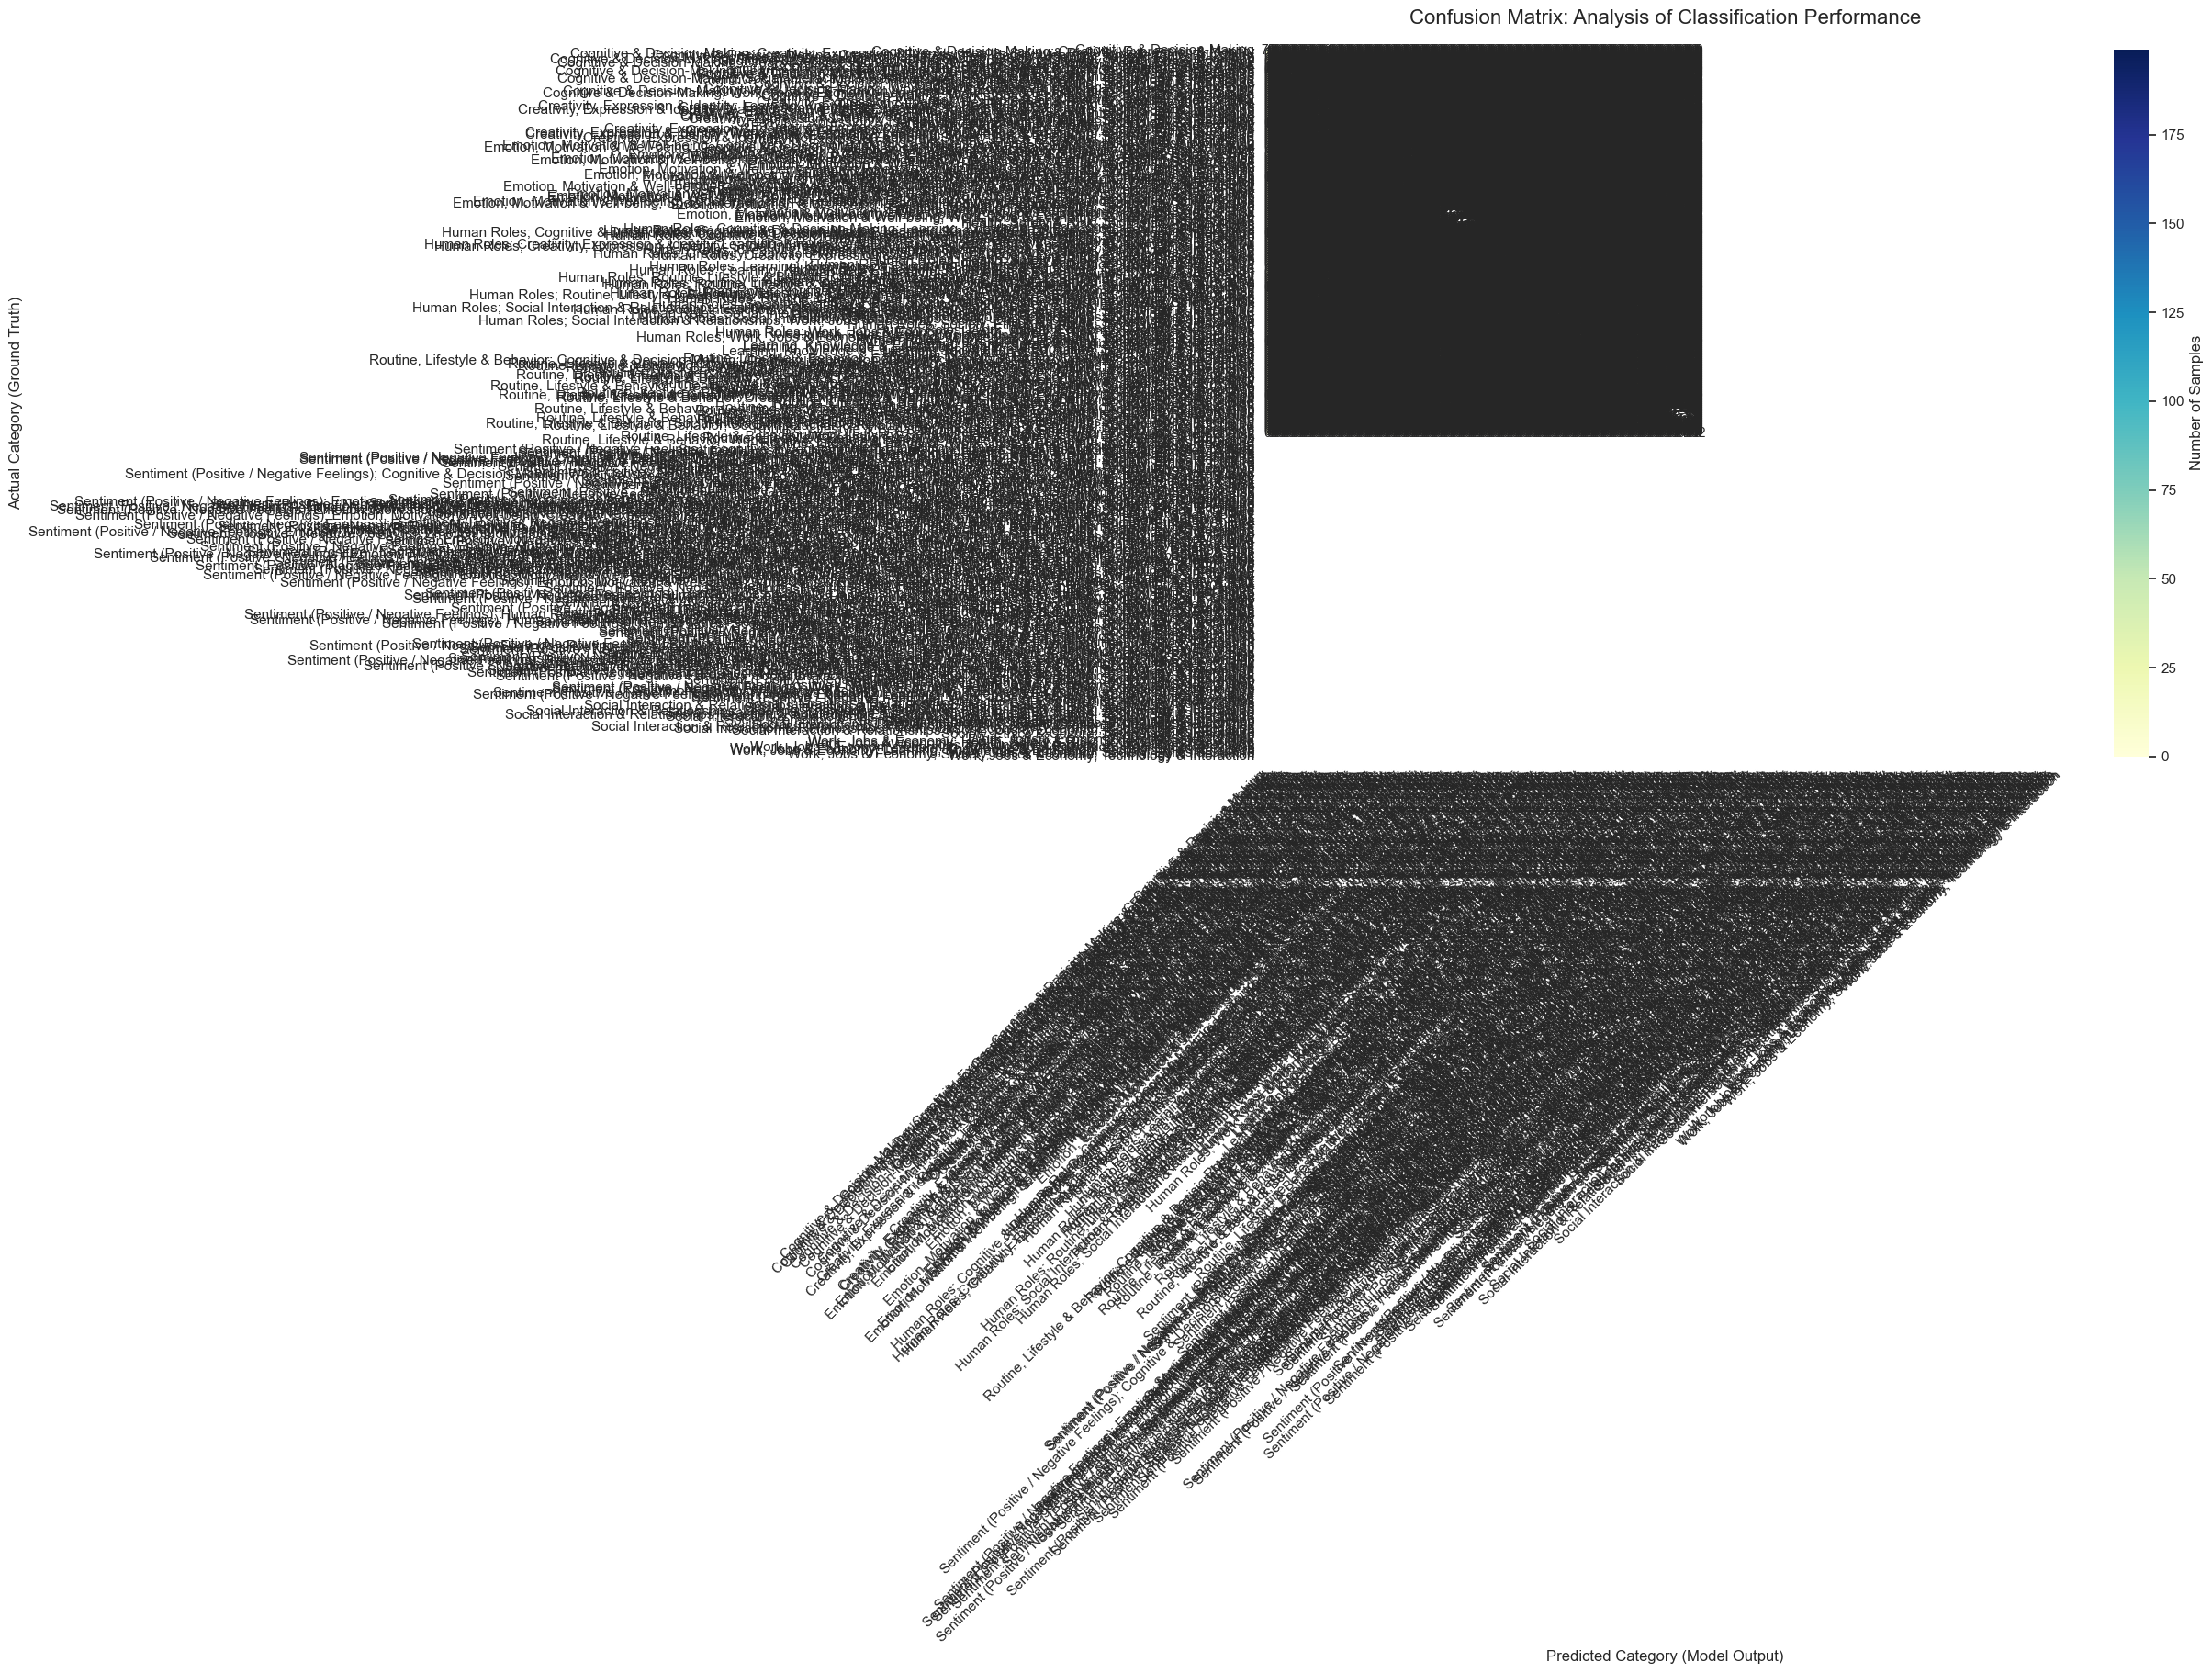


TOP 5 CLASSIFICATION ERRORS (Frequent Confusions)
1. Actual Class: [Cognitive & Decision-Making; Learning, Knowledge & Education; Health, Safety & Risk; Technology & Interaction]
   Mistakenly Predicted as: [Cognitive & Decision-Making]
   Error Count: 6 cases

2. Actual Class: [Emotion, Motivation & Well-being; Routine, Lifestyle & Behavior; Cognitive & Decision-Making]
   Mistakenly Predicted as: [Emotion, Motivation & Well-being; Human Roles; Work, Jobs & Economy]
   Error Count: 5 cases

3. Actual Class: [Human Roles; Learning, Knowledge & Education; Health, Safety & Risk]
   Mistakenly Predicted as: [Human Roles; Health, Safety & Risk; Technology & Interaction]
   Error Count: 5 cases

4. Actual Class: [Human Roles; Learning, Knowledge & Education; Technology & Interaction]
   Mistakenly Predicted as: [Human Roles; Work, Jobs & Economy]
   Error Count: 4 cases

5. Actual Class: [Routine, Lifestyle & Behavior; Social Interaction & Relationships; Work, Jobs & Economy; Learning, Kno

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np
import pandas as pd

# --- STEP 1: Generate Predictions ---
# We need to get the predictions from the trainer first
print("Generating predictions for the validation set...")
output = trainer.predict(val_dataset)
# Convert raw output (logits) to class indices (0, 1, 2...)
preds = np.argmax(output.predictions, axis=-1)

# --- STEP 2: Create Confusion Matrix ---
cm = confusion_matrix(val_labels, preds)
class_names = le.classes_

# --- STEP 3: Enhanced Heatmap for better readability ---
plt.figure(figsize=(14, 10))
sns.set_theme(style="white") 

sns.heatmap(
    cm, 
    annot=True, 
    fmt='d', 
    cmap='YlGnBu', 
    xticklabels=class_names, 
    yticklabels=class_names,
    cbar_kws={'label': 'Number of Samples'},
    annot_kws={"size": 10} 
)

plt.title('Confusion Matrix: Analysis of Classification Performance', fontsize=16, pad=20)
plt.ylabel('Actual Category (Ground Truth)', fontsize=12)
plt.xlabel('Predicted Category (Model Output)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout() 
plt.show()

# --- STEP 4: Analysis: Top 5 Most Frequent Errors ---
print("\n" + "="*50)
print("TOP 5 CLASSIFICATION ERRORS (Frequent Confusions)")
print("="*50)

# Mask the diagonal (correct predictions) to find only the mistakes
mask = np.ones(cm.shape, dtype=bool)
np.fill_diagonal(mask, 0)
errors = cm * mask

# Get indices of the top 5 errors
top_error_indices = np.unravel_index(np.argsort(errors.ravel())[-5:][::-1], errors.shape)

for i in range(5):
    actual_idx = top_error_indices[0][i]
    pred_idx = top_error_indices[1][i]
    count = errors[actual_idx, pred_idx]
    
    actual_name = class_names[actual_idx]
    pred_name = class_names[pred_idx]
    
    # These prints explain exactly which domains the AI finds similar
    print(f"{i+1}. Actual Class: [{actual_name}]")
    print(f"   Mistakenly Predicted as: [{pred_name}]")
    print(f"   Error Count: {count} cases\n")

print("="*50)

In [4]:
import pandas as pd
import torch
import numpy as np
import joblib
import os
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer
from torch.utils.data import Dataset

# 1. Data load & preprocessing
df = pd.read_csv('dataset_A_news_full_10500.csv')

# Encode text labels into numbers
le = LabelEncoder()
df['label'] = le.fit_transform(df['classes_str'])
num_labels = len(le.classes_)

# CRITICAL: Save the LabelEncoder for deployment
# This allows your friends to convert predicted numbers back to category names
joblib.dump(le, "label_encoder.pkl")

# 2. Prepare tokenizer and dataset
model_name = "distilbert-base-uncased" # Lightweight and efficient for personal PCs
tokenizer = AutoTokenizer.from_pretrained(model_name)

class NewsDataset(Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels
    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx])
        return item
    def __len__(self):
        return len(self.labels)

# Split data (80% Training, 20% Validation)
train_texts, val_texts, train_labels, val_labels = train_test_split(
    df['title'].astype(str).tolist(), df['label'].tolist(), test_size=0.2, random_state=42
)

# Tokenize text data
train_encodings = tokenizer(train_texts, truncation=True, padding=True, max_length=64)
val_encodings = tokenizer(val_texts, truncation=True, padding=True, max_length=64)

train_dataset = NewsDataset(train_encodings, train_labels)
val_dataset = NewsDataset(val_encodings, val_labels)

# 3. Set model and define accuracy calculation
model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=num_labels)

# This function calculates Accuracy (%) during the evaluation phase
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    return {"accuracy": accuracy_score(labels, predictions)}

# 4. Training Arguments (Optimized for low RAM and high performance)
training_args = TrainingArguments(
    output_dir='./results',
    num_train_epochs=3,
    per_device_train_batch_size=4,   # Reduced batch size to prevent "Out of Memory"
    per_device_eval_batch_size=4,
    gradient_accumulation_steps=4,  # Actual training batch size is 16 (4*4)
    eval_strategy="epoch",          # Updated syntax from 'evaluation_strategy'
    save_strategy="epoch",
    logging_dir='./logs',
    fp16=torch.cuda.is_available(), # Use Mixed Precision for faster training if GPU is available
    load_best_model_at_end=True,    # Automatically load the most accurate model at the end
    metric_for_best_model="accuracy"
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics  # Added to track Accuracy (%)
)

# 5. Start Training
print("Start training... This may take about 30-40 minutes.")
trainer.train()

# 6. Save the trained model for your friends
# These files are necessary for sharing/deploying the project
save_path = "./my_bert_model"
trainer.save_model(save_path)
tokenizer.save_pretrained(save_path)
print(f"Model saved to {save_path}")

# 7. Final Evaluation
results = trainer.evaluate()
print("\n--- Final Analysis Results ---")
print(f"Validation Accuracy: {results['eval_accuracy'] * 100:.2f}%")

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Start training... This may take about 30-40 minutes.


C:\Users\zxcvz\AppData\Local\Programs\Python\Python312\Lib\site-packages\torch\utils\data\dataloader.py:665: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Epoch,Training Loss,Validation Loss,Accuracy
1,2.953100,1.555578,0.721429
2,1.167200,1.002380,0.823333
3,0.769300,0.883714,0.848095


C:\Users\zxcvz\AppData\Local\Programs\Python\Python312\Lib\site-packages\torch\utils\data\dataloader.py:665: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
C:\Users\zxcvz\AppData\Local\Programs\Python\Python312\Lib\site-packages\torch\utils\data\dataloader.py:665: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Model saved to ./my_bert_model


C:\Users\zxcvz\AppData\Local\Programs\Python\Python312\Lib\site-packages\torch\utils\data\dataloader.py:665: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)



--- Final Analysis Results ---
Validation Accuracy: 84.81%


In [5]:
import joblib
import torch
from transformers import pipeline

# 1. Load the LabelEncoder (Converts numbers to actual names)
# Make sure 'label_encoder.pkl' is in the same folder
le = joblib.load("label_encoder.pkl")

# 2. Load the trained model using the 'pipeline' API
# 'device=-1' means use CPU. Change to 0 if they have a GPU.
model_path = "./my_bert_model"
classifier = pipeline("text-classification", model=model_path, tokenizer=model_path, device=-1)

def predict_news_category(title):
    """
    Function to predict category from a news title
    """
    # Get raw prediction (e.g., {'label': 'LABEL_5', 'score': 0.98})
    result = classifier(title)[0]
    
    # Extract the numeric index from the label string (e.g., 'LABEL_5' -> 5)
    label_idx = int(result['label'].split('_')[-1])
    
    # Convert index to the original class name
    category_name = le.inverse_transform([label_idx])[0]
    confidence = result['score'] * 100
    
    return category_name, confidence

# --- TEST AREA ---
test_title = "New AI technology improves medical diagnosis accuracy"
category, score = predict_news_category(test_title)

print(f"News Title: {test_title}")
print(f"Predicted Category: {category}")
print(f"Confidence Score: {score:.2f}%")

Device set to use cpu


News Title: New AI technology improves medical diagnosis accuracy
Predicted Category: Health, Safety & Risk; Technology & Interaction
Confidence Score: 45.49%


In [6]:
# Updated function to show Top 3 predictions
def predict_top_k(title, k=3):
    # Get all probabilities
    results = classifier(title, top_k=k)
    
    print(f"\n[Input Title]: {title}")
    print("-" * 30)
    
    for i, res in enumerate(results):
        # Extract index and convert to name
        label_idx = int(res['label'].split('_')[-1])
        category_name = le.inverse_transform([label_idx])[0]
        score = res['score'] * 100
        
        print(f"Top {i+1}: {category_name} ({score:.2f}%)")

# Example usage for your teammates
predict_top_k("New AI technology improves medical diagnosis accuracy")


[Input Title]: New AI technology improves medical diagnosis accuracy
------------------------------
Top 1: Health, Safety & Risk; Technology & Interaction (45.49%)
Top 2: Health, Safety & Risk (6.91%)
Top 3: Human Roles; Health, Safety & Risk (4.83%)
